<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 2.
# ARIMA изнутри: как считаются прогноз и интервал

В ноутбуке `01` мы разобрали, из чего собрана модель: лаг-многочлены
$\varphi(L)$ и $\theta(L)$, их корни, ACF и PACF. Но прогноз мы там получали
одним вызовом `res.get_forecast(h)` — то есть чёрным ящиком.

Сегодня ящик открываем. Всё, что вернёт `statsmodels`, мы посчитаем сами в
несколько строк numpy 

> 🔑 **Главная мысль ноутбука.** Прогноз ARIMA — это не «магия оптимизации»,
> а одна короткая рекурсия: *возьми уравнение модели, подставь в него
> будущее, обнули то, чего ещё не знаешь*. А интервал прогноза — это
> разброс той же рекурсии, если в неё подставлять случайные будущие шоки.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Данные и инструменты ноутбука |
| 1 | Рецепт из трёх шагов: как из уравнения получить формулу прогноза |
| 2 | MA($q$): прогноз руками и почему он «выключается» через $q$ шагов |
| 3 | AR($p$): бесконечная память и геометрическое затухание к среднему |
| 4 | Полный разбор ARIMA(3,1,1): уравнение с числами → прогноз → сверка |
| 5 | Интервалы: откуда берётся ширина и почему $v_{T+1\mid T} = \hat\sigma^2$ всегда |
| 6 | Роль $c$ и $d$: шесть форм долгосрочного прогноза |
| 7 | Как $d$ влияет на скорость расширения интервалов |
| 8 | Почему интервалы ARIMA систематически **слишком узкие** |


In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess, arma2ma
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from utils import tsdisplay

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

print("statsmodels:", sm.__version__)

statsmodels: 0.14.6


---
# 0. Данные и инструменты



In [5]:
SEED = 20240404

def rng():
    """Свежий генератор с фиксированным зерном — воспроизводимые картинки."""
    return np.random.default_rng(SEED)

## 0.2. Два ряда на весь ноутбук

Нам понадобятся:

* **US consumption** (`us_change.csv`) — квартальный прирост потребительских
  расходов в США, в процентах. Ряд уже стационарен ($d = 0$), поэтому на нём
  удобно проверять формулы для ARMA;
* **логарифм цены закрытия GOOGL** (`GOOGL.csv`) — типичная финансовая
  «единичнокорневая» кривая, на ней будем разбирать случай $d = 1$.

Логарифм берём по правилу 15 из ноутбука `1.03`: сначала стабилизируем
дисперсию, потом дифференцируем.

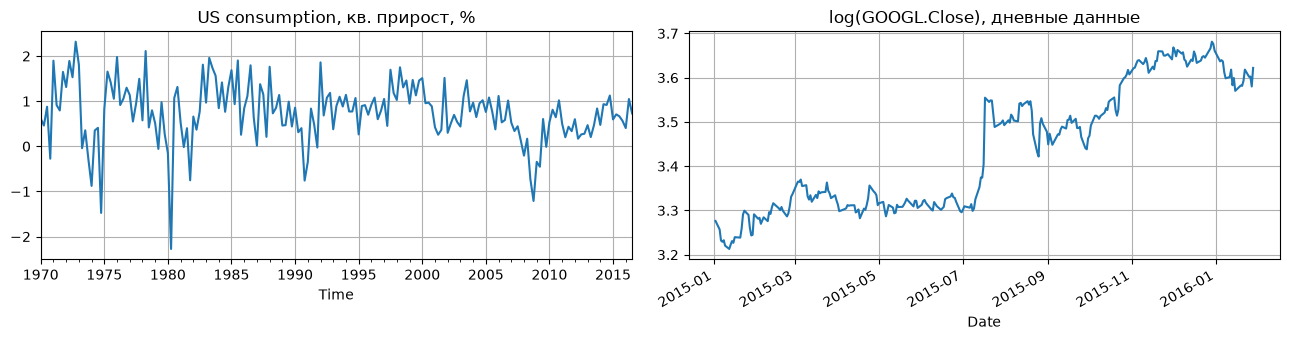

US consumption: 187 наблюдений
GOOGL:          270 наблюдений


In [6]:
us = pd.read_csv("../data/us_change.csv", parse_dates=["Time"]).set_index("Time")
us.index.freq = "QS"
consumption = us["Consumption"]

googl = pd.read_csv("../data/GOOGL.csv", parse_dates=["Date"]).set_index("Date")["Close"]
log_googl = np.log(googl)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
consumption.plot(ax=axes[0], title="US consumption, кв. прирост, %")
log_googl.plot(ax=axes[1], title="log(GOOGL.Close), дневные данные")
fig.tight_layout()
plt.show()

print("US consumption:", len(consumption), "наблюдений")
print("GOOGL:         ", len(log_googl), "наблюдений")

🔍 **Техническая деталь, о которую все спотыкаются.** Если подать в `ARIMA`
ряд с `DatetimeIndex`, то `get_forecast(...).conf_int()` вернёт
`DataFrame` (с датами в индексе), а если numpy-массив — `ndarray`. Код вида
`ci[:, 0]` работает только во втором случае. Чтобы не думать об этом каждый
раз, будем оборачивать результат в `np.asarray(...)`.

То же самое с `res.params`: для `Series` на входе это `Series` (и можно
писать `params["sigma2"]`), для массива — `ndarray` (и надо знать номер).
Заведём маленькую функцию, которая работает в обоих случаях.

Для разделов с ручным счётом удобнее вообще работать с «голым» массивом:
индекс там только мешает.

In [7]:
y_googl = log_googl.to_numpy()          # для ручных вычислений
y_cons = consumption.to_numpy()


def sigma2_of(res):
    """Оценка дисперсии шока sigma^2 — независимо от типа входных данных."""
    return float(np.asarray(res.params)[res.param_names.index("sigma2")])

---
# 1. Рецепт из трёх шагов

Всё содержание раздела «прогнозирование ARIMA» умещается в три строчки.
Пусть модель записана в виде уравнения. Тогда прогноз на $h$ шагов вперёд
получается так:

> **Шаг 1.** Разверните уравнение модели так, чтобы $y_t$ стояло **слева**,
> а всё остальное — справа.
>
> **Шаг 2.** Замените всюду $t$ на $T + h$, где $T$ — момент, из которого
> прогнозируем.
>
> **Шаг 3.** В правой части сделайте три замены:
> * **будущие наблюдения** $y_{T+k},\ k > 0$ → их прогнозы $\hat y_{T+k}$;
> * **будущие ошибки** $\varepsilon_{T+k},\ k > 0$ → **нули**;
> * **прошлые ошибки** $\varepsilon_{T-k},\ k \ge 0$ → остатки модели $e_{T-k}$.

Почему именно так? Прогноз — это условное математическое ожидание
$\hat y_{T+h} = \mathbb{E}[y_{T+h} \mid y_1, \dots, y_T]$. Ожидание линейно,
поэтому оно «проходит внутрь» уравнения; ожидание будущего шока равно нулю
($\mathbb{E}\varepsilon_{T+k} = 0$), а прошлые шоки уже реализовались и нам
известны — точнее, известны их оценки, то есть остатки.

## 1.1. Пример на бумаге: ARIMA(1,1,1)

Запишем модель через лаг-оператор и раскроем скобки:

$$ (1 - \varphi_1 L)(1 - L)\, y_t = (1 + \theta_1 L)\, \varepsilon_t $$

$$ \big(1 - (1 + \varphi_1) L + \varphi_1 L^2\big) y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} $$

**Шаг 1** — переносим всё, кроме $y_t$, вправо:

$$ y_t = (1 + \varphi_1)\, y_{t-1} - \varphi_1\, y_{t-2} + \varepsilon_t + \theta_1 \varepsilon_{t-1}. $$

**Шаг 2 и 3** для $h = 1$ (всё, что справа, уже известно):

$$ \hat y_{T+1} = (1 + \varphi_1)\, y_T - \varphi_1\, y_{T-1} + \theta_1 e_T. $$

Для $h = 2$ значение $y_{T+1}$ ещё не наблюдалось — заменяем его прогнозом,
а $\varepsilon_{T+1}$ обнуляем:

$$ \hat y_{T+2} = (1 + \varphi_1)\, \hat y_{T+1} - \varphi_1\, y_T. $$

🔑 Обратите внимание на важную деталь: **MA-часть исчезает из формулы при
$h > q$**. У MA(1) уже на втором шаге не остаётся ни одной известной ошибки —
все они «будущие», а значит нули. Это не особенность примера, а общее
свойство, и в разделе 2 мы увидим его на графике.

## 1.2. Что такое «остатки модели»

Остаток $e_t$ — это **ошибка прогноза на один шаг вперёд**, сделанного из
момента $t-1$:

$$ e_t = y_t - \hat y_{t \mid t-1}. $$

В `statsmodels` они лежат в `res.resid`, а сами одношаговые прогнозы —
в `res.fittedvalues`. Проверим тождество на реальной модели.

In [8]:
res_demo = ARIMA(consumption, order=(1, 0, 1), trend="c").fit()

check = pd.DataFrame({
    "y": consumption,
    "прогноз на 1 шаг": res_demo.fittedvalues,
    "остаток": res_demo.resid,
})
check["y - прогноз"] = check["y"] - check["прогноз на 1 шаг"]
check.tail(4).round(6)

,y,прогноз на 1 шаг,остаток,y - прогноз
Time,,,,
2015-10-01,0.561680,0.722877,-0.161198,-0.161198
2016-01-01,0.404682,0.682002,-0.277320,-0.277320
2016-04-01,1.047707,0.617128,0.430579,0.430579
2016-07-01,0.729598,0.766581,-0.036983,-0.036983


Столбцы «остаток» и «y − прогноз» совпадают — это одно и то же по
определению.

🔍 **А первое наблюдение?** У самого начала ряда никакого прошлого нет, и
рекурсия стартует с некоторого предположения (в `statsmodels` — с
диффузной инициализации фильтра Калмана). Поэтому первые несколько остатков
«искусственные», и на них не стоит смотреть. Для нас это неважно: в прогнозе
участвуют **последние** остатки, а к концу длинного ряда влияние старта
давно затухло. Но у этого «давно затухло» есть исключение, и в разделе 4.4
мы на него наткнёмся.

In [9]:
res_demo.resid.head(3).round(4)

Time
1970-01-01   -0.1287
1970-04-01   -0.2369
1970-07-01    0.2412
Freq: QS-JAN, dtype: float64

---
# 2. Прогноз MA($q$) руками

Начнём с самой простой модели, потому что на ней рецепт из трёх шагов виден
целиком, без рекурсии.

$$ y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q} $$

Применяем рецепт для $h = 1, 2, 3$ при $q = 2$:

$$ \hat y_{T+1} = \mu + \theta_1 e_T + \theta_2 e_{T-1}, $$
$$ \hat y_{T+2} = \mu + \theta_2 e_T, $$
$$ \hat y_{T+3} = \mu. $$

🔑 **Прогноз MA($q$) выходит на постоянный уровень $\mu$ ровно за $q$
шагов** — и дальше не меняется никогда. Память процесса конечна: он помнит
только последние $q$ шоков, а через $q$ шагов все они окажутся в «будущем»,
то есть обнулятся.

Проверим это численно. Сгенерируем MA(2), подгоним модель и посчитаем
прогноз двумя способами.

🔍 Параметры $\theta$ выбраны так, чтобы процесс был **обратим** — иначе
сравнивать оценки с истиной бессмысленно: `statsmodels` всегда вернёт
обратимого двойника с теми же ACF и прогнозами, но другими числами
(ноутбук `01`, раздел 2). Проверка — одна строка.

In [10]:
theta_true = [0.5, -0.3]
mu_true = 5.0

process_ma = ArmaProcess.from_coeffs([], theta_true)
print("процесс обратим:", process_ma.isinvertible)   # см. ноутбук 01, раздел 2

y_ma = mu_true + process_ma.generate_sample(400, distrvs=rng().standard_normal)

res_ma = ARIMA(y_ma, order=(0, 0, 2), trend="c").fit()

print("оценки: mu =", round(res_ma.params[0], 4),
      " theta =", np.round(res_ma.maparams, 4))
print("истина: mu = 5.0    theta =", theta_true)

процесс обратим: True
оценки: mu = 4.9936  theta = [ 0.4934 -0.247 ]
истина: mu = 5.0    theta = [0.5, -0.3]


In [11]:
mu_hat = res_ma.params[0]
th = res_ma.maparams
e = res_ma.resid

manual = np.array([
    mu_hat + th[0] * e[-1] + th[1] * e[-2],   # h = 1
    mu_hat + th[1] * e[-1],                   # h = 2
    mu_hat,                                   # h = 3
    mu_hat,                                   # h = 4
])

sm_fc = res_ma.get_forecast(4).predicted_mean

pd.DataFrame({
    "руками": manual,
    "statsmodels": np.asarray(sm_fc),
    "разница": manual - np.asarray(sm_fc),
}, index=pd.Index([1, 2, 3, 4], name="h"))

,руками,statsmodels,разница
h,,,
1,5.858954,5.858954,0.0
2,4.596719,4.596719,0.0
3,4.993622,4.993622,0.0
4,4.993622,4.993622,0.0


Совпадение до $10^{-12}$ — то есть до машинной точности. Формула из трёх
строчек воспроизводит библиотеку в точности.

Нарисуем, как выглядит это «выключение» MA-части.

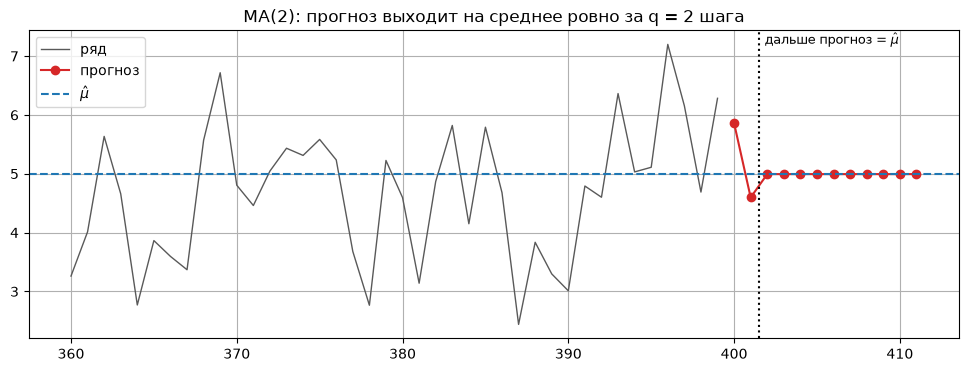

In [12]:
h = 12
fc_ma = res_ma.get_forecast(h)

fig, ax = plt.subplots(figsize=(12, 4))
tail = 40
ax.plot(np.arange(len(y_ma) - tail, len(y_ma)), y_ma[-tail:], lw=1, color="0.35", label="ряд")
idx = np.arange(len(y_ma), len(y_ma) + h)
ax.plot(idx, fc_ma.predicted_mean, "o-", color="tab:red", label="прогноз")
ax.axhline(mu_hat, ls="--", color="tab:blue", label=r"$\hat\mu$")
ax.axvline(len(y_ma) + 1.5, ls=":", color="k")
ax.text(len(y_ma) + 1.6, y_ma[-tail:].max(), " дальше прогноз = $\\hat\\mu$", fontsize=9)
ax.set_title("MA(2): прогноз выходит на среднее ровно за q = 2 шага")
ax.legend()
plt.show()

---
# 3. Прогноз AR($p$) руками

У AR всё наоборот: память бесконечная, но затухающая.

$$ y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t $$

По рецепту:

$$ \hat y_{T+1} = c + \varphi_1 y_T + \dots + \varphi_p y_{T-p+1}, $$
$$ \hat y_{T+2} = c + \varphi_1 \hat y_{T+1} + \varphi_2 y_T + \dots $$

и так далее: с каждым шагом в правой части реальных наблюдений становится
меньше, а прогнозов — больше. Через $p$ шагов реальных данных не остаётся
вовсе, и рекурсия начинает «питаться собой».

🔍 **Здесь живёт самая частая ошибка из ноутбука `01`.** В `summary()`
выводится строка `const`, но это **не** $c$ из уравнения, а среднее $\mu$.
Связь: $c = \mu\,(1 - \varphi_1 - \dots - \varphi_p)$. Посчитаем прогноз
AR(2) обоими способами и посмотрим на цену ошибки.

In [13]:
res_ar = ARIMA(consumption, order=(2, 0, 0), trend="c").fit()

mu = res_ar.params["const"]
phi = res_ar.arparams
c = mu * (1 - phi.sum())

print(f"const из summary (это mu): {mu:.4f}")
print(f"интерсепт c = mu(1 - sum(phi)) = {c:.4f}")
print(f"phi = {np.round(phi, 4)}")

# правильно: через отклонения от среднего либо через c
right = c + phi[0] * y_cons[-1] + phi[1] * y_cons[-2]
wrong = mu + phi[0] * y_cons[-1] + phi[1] * y_cons[-2]

print(f"\nправильно:            {right:.6f}")
print(f"statsmodels:          {res_ar.get_forecast(1).predicted_mean.iloc[0]:.6f}")
print(f"если перепутать c и mu: {wrong:.6f}   ← ошибка {wrong - right:+.3f}")

const из summary (это mu): 0.7457
интерсепт c = mu(1 - sum(phi)) = 0.3814
phi = [0.272  0.2166]

правильно:            0.806757
statsmodels:          0.806757
если перепутать c и mu: 1.171148   ← ошибка +0.364


Ошибка в полпроцентного пункта на ряду со средним 0.75 — это очень много.

Теперь развернём рекурсию на много шагов вперёд и посмотрим, как прогноз
AR(2) сходится к среднему.

максимальное расхождение: 2.220446049250313e-16


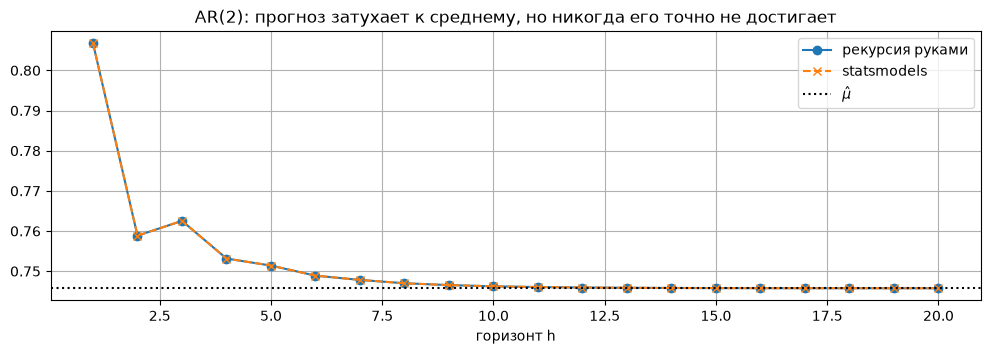

In [14]:
def ar_forecast_manual(y, c, phi, h):
    """Рекурсия «прогноз питается собственными прогнозами» для AR(p) с интерсептом c."""
    hist = list(y[-len(phi):])          # последние p наблюдений
    out = []
    for _ in range(h):
        nxt = c + float(np.dot(phi, hist[::-1]))
        out.append(nxt)
        hist = (hist + [nxt])[-len(phi):]
    return np.array(out)


H = 20
man_ar = ar_forecast_manual(y_cons, c, phi, H)
sm_ar = np.asarray(res_ar.get_forecast(H).predicted_mean)

print("максимальное расхождение:", np.abs(man_ar - sm_ar).max())

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(np.arange(1, H + 1), man_ar, "o-", label="рекурсия руками")
ax.plot(np.arange(1, H + 1), sm_ar, "x--", label="statsmodels")
ax.axhline(mu, ls=":", color="k", label=r"$\hat\mu$")
ax.set_xlabel("горизонт h")
ax.set_title("AR(2): прогноз затухает к среднему, но никогда его точно не достигает")
ax.legend()
plt.show()

🔑 Сравните с MA(2): там прогноз **приходит** на уровень $\mu$ за два шага и
садится на него точно, здесь — **приближается** к нему бесконечно долго со
скоростью геометрической прогрессии. Это ровно та же разница, что между
конечной и бесконечной памятью из ноутбука `01`.

---
# 4. Полный разбор ARIMA(3,1,1)

Соберём всё вместе на модели с $d = 1$ — здесь появляется единственная новая
деталь: интегрирование.

## 4.1. Уравнение с числами

Модель ARIMA(3,1,1) без константы:

$$ (1 - \varphi_1 L - \varphi_2 L^2 - \varphi_3 L^3)(1 - L)\, y_t
   = (1 + \theta_1 L)\, \varepsilon_t. $$

Раскроем произведение слева (это обычное умножение многочленов):

$$ \big(1 - (1+\varphi_1) L + (\varphi_1 - \varphi_2) L^2
     + (\varphi_2 - \varphi_3) L^3 + \varphi_3 L^4 \big) y_t = \dots $$

и перенесём всё, кроме $y_t$, вправо (**шаг 1** рецепта):

$$ y_t = (1+\varphi_1)\, y_{t-1} - (\varphi_1 - \varphi_2)\, y_{t-2}
         - (\varphi_2 - \varphi_3)\, y_{t-3} - \varphi_3\, y_{t-4}
         + \varepsilon_t + \theta_1 \varepsilon_{t-1}. $$

🔍 Обратите внимание: у ARIMA(3,1,1) в развёрнутом виде **четыре** лага
$y$, хотя $p = 3$. Разность добавляет один лаг: порядок AR-части после
раскрытия скобок равен $p + d$.

Подгоним модель на логарифме цены GOOGL и выпишем это уравнение с числами.

In [15]:
res_311 = ARIMA(y_googl, order=(3, 1, 1), trend="n").fit()
print(res_311.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0428      0.561      0.076      0.939      -1.057       1.143
ar.L2         -0.0181      0.089     -0.203      0.839      -0.193       0.156
ar.L3         -0.0905      0.061     -1.477      0.140      -0.211       0.030
ma.L1          0.0415      0.556      0.075      0.940      -1.049       1.132
sigma2         0.0003   1.28e-05     24.758      0.000       0.000       0.000


In [16]:
def expanded_ar_poly(res):
    """Коэффициенты при лагах y после раскрытия (1 - phi(L))(1 - L)^d."""
    poly = np.r_[1.0, -res.arparams]           # phi(L)
    for _ in range(res.model.order[1]):        # умножаем на (1 - L) d раз
        poly = np.polymul(poly, np.r_[1.0, -1.0])
    return -poly[1:]                           # коэффициенты справа от знака =


coefs_y = expanded_ar_poly(res_311)

terms = " ".join(
    f"{coef:+.4f}·y_{{t-{i + 1}}}" for i, coef in enumerate(coefs_y)
)
print("y_t =", terms, f"+ eps_t {res_311.maparams[0]:+.4f}·eps_(t-1)")
print("\nпроверка: сумма коэффициентов при y =", round(coefs_y.sum(), 4),
      "(близка к 1 — это и есть единичный корень, который мы убрали разностью)")

y_t = +1.0428·y_{t-1} -0.0608·y_{t-2} -0.0725·y_{t-3} +0.0905·y_{t-4} + eps_t +0.0415·eps_(t-1)

проверка: сумма коэффициентов при y = 1.0 (близка к 1 — это и есть единичный корень, который мы убрали разностью)


## 4.2. Прогноз на 1, 2 и 3 шага

Считаем строго по рецепту. Удобнее работать не с самим $y$, а с разностью
$w_t = \nabla y_t = y_t - y_{t-1}$: для неё модель — обычная ARMA(3,1), без
всяких скобок.

$$ w_t = \varphi_1 w_{t-1} + \varphi_2 w_{t-2} + \varphi_3 w_{t-3}
       + \varepsilon_t + \theta_1 \varepsilon_{t-1}. $$

Прогнозируем $w$, а потом **интегрируем обратно** — накопленной суммой:
$\hat y_{T+h} = y_T + \hat w_{T+1} + \dots + \hat w_{T+h}$.

In [17]:
phi3, th1 = res_311.arparams, res_311.maparams[0]
w = np.diff(y_googl)               # ряд разностей
e = np.asarray(res_311.resid)[1:]  # остатки, выровненные по w (первый отброшен)

# h = 1: все слагаемые известны
w1 = phi3 @ w[[-1, -2, -3]] + th1 * e[-1]
# h = 2: w_{T+1} заменяем прогнозом, eps_{T+1} = 0 -> MA-часть исчезает
w2 = phi3 @ np.r_[w1, w[-1], w[-2]]
# h = 3: два последних значения — уже прогнозы
w3 = phi3 @ np.r_[w2, w1, w[-1]]

manual_311 = y_googl[-1] + np.cumsum([w1, w2, w3])
sm_311 = np.asarray(res_311.get_forecast(3).predicted_mean)

pd.DataFrame({
    "прогноз разности ŵ": [w1, w2, w3],
    "руками (уровень)": manual_311,
    "statsmodels": sm_311,
    "разница": manual_311 - sm_311,
}, index=pd.Index([1, 2, 3], name="h"))

,прогноз разности ŵ,руками (уровень),statsmodels,разница
h,,,,
1,0.003931,3.626003,3.626003,4.182343e-11
2,0.001433,3.627436,3.627436,4.361178e-11
3,-0.003804,3.623632,3.623632,4.293321e-11


Расхождение порядка $10^{-11}$ — это накопленная ошибка округления чисел с
плавающей точкой. Никакого другого алгоритма внутри `.predict()` нет.

## 4.3. Универсальная функция

Оформим рекурсию в функцию, которая работает для любых $(p, d, q)$ — она нам
ещё пригодится.

In [18]:
def manual_arima_forecast(res, y, h):
    """Прогноз ARIMA(p,d,q) без константы «по рецепту трёх шагов».

    1) переходим к w = ∇^d y — для неё модель это обычная ARMA;
    2) рекурсия: будущие w заменяем прогнозами, будущие eps — нулями;
    3) интегрируем обратно d раз накопленной суммой.
    """
    phi, theta = res.arparams, res.maparams
    d = res.model.order[1]
    y = np.asarray(y, dtype=float)

    w = list(np.diff(y, n=d))               # при d = 0 это просто сам ряд
    eps = list(np.asarray(res.resid)[d:])   # остатки, выровненные по w

    for _ in range(h):
        nxt = sum(phi[j] * w[-1 - j] for j in range(len(phi)))
        nxt += sum(theta[j] * eps[-1 - j] for j in range(len(theta)))
        w.append(nxt)
        eps.append(0.0)                     # будущий шок = 0

    fc = np.array(w[-h:])
    for k in range(d, 0, -1):               # интегрируем: ∇^k y -> ∇^{k-1} y
        fc = np.diff(y, n=k - 1)[-1] + np.cumsum(fc)
    return fc

In [19]:
rows = []
for order in [(3, 1, 1), (1, 1, 1), (1, 1, 0), (0, 1, 0), (2, 2, 1)]:
    r = ARIMA(y_googl, order=order, trend="n").fit()
    man = manual_arima_forecast(r, y_googl, 6)
    sm_ = np.asarray(r.get_forecast(6).predicted_mean)
    rows.append({
        "модель": f"ARIMA{order}",
        "прогноз h=1, руками": man[0],
        "макс. расхождение по h=1..6": np.abs(man - sm_).max(),
    })

pd.DataFrame(rows)

,модель,"прогноз h=1, руками",макс. расхождение по h=1..6
0,"ARIMA(3, 1, 1)",3.626003,4.361178e-11
1,"ARIMA(1, 1, 1)",3.625564,4.409806e-13
2,"ARIMA(1, 1, 0)",3.625833,4.440892e-16
3,"ARIMA(0, 1, 0)",3.622072,0.000000e+00
4,"ARIMA(2, 2, 1)",3.627828,7.618641e-04


🔍 Функция написана для моделей **без константы** — это типичный случай при
$d \ge 1$. Чтобы добавить константу, достаточно прибавлять $c$ внутри цикла
(см. задание 3).



---
# 5. Интервалы прогноза

## 5.1. Откуда берётся ширина

Точечный прогноз — это ожидание. Интервал — это разброс вокруг него.
Обозначим **дисперсию ошибки прогноза** на $h$ шагов

$$ v_{T+h \mid T} = \mathrm{Var}\big(y_{T+h} - \hat y_{T+h} \mid y_1, \dots, y_T\big). $$

Если ошибки нормальны, то интервал уровня $100(1-\alpha)\%$ — это

$$ \hat y_{T+h} \pm z_{1 - \alpha/2}\, \sqrt{v_{T+h \mid T}}, \qquad
   z_{0.975} \approx 1.96. $$

Всё содержание раздела — как посчитать $v_{T+h\mid T}$.

Ключевой инструмент — представление MA($\infty$) из ноутбука `01`:
любой стационарный ARMA можно записать как
$y_t = \mu + \sum_{j \ge 0} \psi_j \varepsilon_{t-j}$, где $\psi_0 = 1$.
Тогда ошибка прогноза — это просто сумма ещё не случившихся шоков:

$$ y_{T+h} - \hat y_{T+h} = \sum_{j=0}^{h-1} \psi_j\, \varepsilon_{T+h-j}
   \quad \Longrightarrow \quad
   \boxed{\;v_{T+h \mid T} = \sigma^2 \sum_{j=0}^{h-1} \psi_j^2\;} $$

Шоки некоррелированы, поэтому дисперсии просто складываются. Из этой одной
формулы следуют все частные случаи ниже.

In [21]:
alpha = 0.05
z = stats.norm.ppf(1 - alpha / 2)
print(f"z_(1-alpha/2) при alpha = 0.05: {z:.6f}")

z_(1-alpha/2) при alpha = 0.05: 1.959964


## 5.2. Первый шаг: $v_{T+1 \mid T} = \hat\sigma^2$ — всегда

При $h = 1$ в сумме остаётся одно слагаемое, $\psi_0^2 = 1$. Значит:

$$ v_{T+1 \mid T} = \sigma^2 $$

🔑 **для любой ARIMA, независимо от $p$, $d$, $q$ и наличия константы.**
Одношаговый интервал — это всегда $\hat y_{T+1} \pm 1.96\,\hat\sigma$.
Проверим на пяти разных моделях.

In [22]:
rows = []
for order in [(0, 0, 0), (2, 0, 1), (1, 1, 1), (2, 1, 0), (1, 1, 2)]:
    trend = "c" if order[1] == 0 else "n"
    r = ARIMA(consumption, order=order, trend=trend).fit()
    se1 = np.asarray(r.get_forecast(1).se_mean)[0]
    sigma = np.sqrt(sigma2_of(r))
    rows.append({
        "модель": f"ARIMA{order}",
        "sqrt(sigma2)": sigma,
        "se прогноза при h=1": se1,
        "отношение": se1 / sigma,
    })

pd.DataFrame(rows).round(6)

,модель,sqrt(sigma2),se прогноза при h=1,отношение
0,"ARIMA(0, 0, 0)",0.653589,0.653589,1.0
1,"ARIMA(2, 0, 1)",0.591372,0.591372,1.0
2,"ARIMA(1, 1, 1)",0.619836,0.619836,1.0
3,"ARIMA(2, 1, 0)",0.618645,0.618645,1.0
4,"ARIMA(1, 1, 2)",0.618154,0.618154,1.0


Отношение равно единице во всех строках.

🔍 Если вы встретите модель, где отношение отличается от 1 в четвёртом
знаке, — это тот же эффект, что в разделе 4.4: почти единичный корень в
MA-части, фильтр Калмана не успел «забыть» инициализацию. Практический вывод
тот же — пересмотреть $d$.

## 5.3. MA($q$): формула в явном виде

У MA($q$) веса $\psi$ — это просто коэффициенты $\theta$:
$\psi_0 = 1$, $\psi_j = \theta_j$ при $j \le q$ и $\psi_j = 0$ дальше. Значит

$$ v_{T+h \mid T} = \sigma^2 \Big( 1 + \sum_{i=1}^{h-1} \theta_i^2 \Big),
   \qquad \theta_i = 0 \ \text{ при } i > q. $$

Интервал расширяется первые $q$ шагов, а потом **перестаёт**: и прогноз, и
его неопределённость выходят на постоянный уровень.

In [23]:
res_ma2 = ARIMA(consumption, order=(0, 0, 2), trend="c").fit()

th = res_ma2.maparams
sigma2 = sigma2_of(res_ma2)

manual_se = np.array([
    np.sqrt(sigma2 * (1 + np.sum(th[:hh - 1] ** 2))) for hh in range(1, 6)
])
sm_se = np.asarray(res_ma2.get_forecast(5).se_mean)

pd.DataFrame({
    "руками": manual_se,
    "statsmodels": sm_se,
    "разница": manual_se - sm_se,
}, index=pd.Index(range(1, 6), name="h")).round(10)

,руками,statsmodels,разница
h,,,
1,0.614720,0.614720,0.0
2,0.629149,0.629149,0.0
3,0.637925,0.637925,0.0
4,0.637925,0.637925,0.0
5,0.637925,0.637925,0.0


## 5.4. AR(1): интервал через представление MA($\infty$)

Для AR(1) веса нам известны из ноутбука `01`: $\psi_j = \varphi_1^{\,j}$.
Подставляем в общую формулу и получаем сумму геометрической прогрессии:

$$ v_{T+h \mid T} = \sigma^2 \sum_{j=0}^{h-1} \varphi_1^{2j}
   = \sigma^2\, \frac{1 - \varphi_1^{2h}}{1 - \varphi_1^{2}}
   \ \xrightarrow[h \to \infty]{}\ \frac{\sigma^2}{1 - \varphi_1^2}
   = \mathrm{Var}(y_t). $$

🔑 Предел — это **безусловная дисперсия ряда**. Содержательно: на далёком
горизонте модель не знает о будущем ничего сверх того, что ряд колеблется
вокруг своего среднего с обычным для себя разбросом. Так ведёт себя интервал
любой стационарной модели.

In [24]:
res_ar1 = ARIMA(consumption, order=(1, 0, 0), trend="c").fit()

phi1 = res_ar1.arparams[0]
sigma2 = sigma2_of(res_ar1)
H = 12
hh = np.arange(1, H + 1)

by_formula = np.sqrt(sigma2 * (1 - phi1 ** (2 * hh)) / (1 - phi1 ** 2))
by_psi = np.sqrt(sigma2 * np.cumsum(arma2ma(np.r_[1, -phi1], np.r_[1], lags=H) ** 2))
by_sm = np.asarray(res_ar1.get_forecast(H).se_mean)

pd.DataFrame({
    "формула прогрессии": by_formula,
    "через psi (arma2ma)": by_psi,
    "statsmodels": by_sm,
}, index=pd.Index(hh, name="h")).round(8).head(6)

,формула прогрессии,через psi (arma2ma),statsmodels
h,,,
1,0.612259,0.612259,0.612259
2,0.648301,0.648301,0.648301
3,0.652535,0.652535,0.652535
4,0.653046,0.653046,0.653046
5,0.653108,0.653108,0.653108
6,0.653115,0.653115,0.653115


In [25]:
print("предел sigma/sqrt(1-phi^2) =", round(np.sqrt(sigma2 / (1 - phi1 ** 2)), 5))
print("std ряда                   =", round(consumption.std(), 5))

предел sigma/sqrt(1-phi^2) = 0.65312
std ряда                   = 0.65535


## 5.5. Общий случай: $\psi$-веса для любой ARIMA

Формула $v_{T+h} = \sigma^2 \sum_{j<h} \psi_j^2$ работает и при $d \ge 1$ —
надо только правильно посчитать $\psi_j$. Разность — это часть AR-многочлена:
берём $\varphi(L)\,(1-L)^d$ и подаём в `arma2ma`.

🔍 При $d \ge 1$ веса $\psi_j$ **не** затухают (для случайного блуждания они
все равны 1) — поэтому дисперсия растёт неограниченно. Это ровно то, что мы
видели на картинках в ноутбуке `01`.

In [26]:
def manual_arima_se(res, h):
    """Стандартная ошибка прогноза ARIMA через psi-веса представления MA(inf)."""
    ar_poly = np.r_[1.0, -res.arparams]
    for _ in range(res.model.order[1]):
        ar_poly = np.polymul(ar_poly, np.r_[1.0, -1.0])
    psi = arma2ma(ar_poly, np.r_[1.0, res.maparams], lags=h)
    return np.sqrt(sigma2_of(res) * np.cumsum(psi ** 2))


rows = []
for order in [(3, 1, 1), (1, 1, 1), (1, 1, 0), (0, 1, 0)]:
    r = ARIMA(y_googl, order=order, trend="n").fit()
    man = manual_arima_se(r, 10)
    sm_ = np.asarray(r.get_forecast(10).se_mean)
    rows.append({"модель": f"ARIMA{order}", "макс. расхождение se": np.abs(man - sm_).max()})

pd.DataFrame(rows)

,модель,макс. расхождение se
0,"ARIMA(3, 1, 1)",2.119777e-10
1,"ARIMA(1, 1, 1)",4.870486e-12
2,"ARIMA(1, 1, 0)",1.065782e-11
3,"ARIMA(0, 1, 0)",4.523283e-09


Соберём точечный прогноз и интервал целиком руками и сравним с
`get_forecast().conf_int()`.

In [27]:
res_pi = ARIMA(y_googl, order=(1, 1, 1), trend="n").fit()
H = 10

point = manual_arima_forecast(res_pi, y_googl, H)
se = manual_arima_se(res_pi, H)
lo_man, hi_man = point - z * se, point + z * se

ci_sm = np.asarray(res_pi.get_forecast(H).conf_int())

pd.DataFrame({
    "нижняя, руками": lo_man,
    "нижняя, sm": ci_sm[:, 0],
    "верхняя, руками": hi_man,
    "верхняя, sm": ci_sm[:, 1],
}, index=pd.Index(range(1, H + 1), name="h")).round(6)

,"нижняя, руками","нижняя, sm","верхняя, руками","верхняя, sm"
h,,,,
1,3.590507,3.590507,3.660620,3.660620
2,3.574213,3.574213,3.677617,3.677617
3,3.561608,3.561608,3.690293,3.690293
4,3.551061,3.551061,3.700847,3.700847
5,3.541822,3.541822,3.710087,3.710087
6,3.533501,3.533501,3.718408,3.718408
7,3.525869,3.525869,3.726040,3.726040
8,3.518780,3.518780,3.733129,3.733129
9,3.512131,3.512131,3.739778,3.739778


## 5.6. Тот же интервал, но через симуляцию

Есть третий способ посмотреть на интервал — не аналитический. Возьмём
оценённую модель и **разыграем будущее много раз**: подставим в рекурсию не
нули вместо будущих шоков, а случайные нормальные величины с дисперсией
$\hat\sigma^2$. Получим «пучок спагетти» — облако возможных траекторий.

Тогда:

* точечный прогноз — это **среднее** траекторий;
* 95%-й интервал — это **2.5%-й и 97.5%-й квантили** траекторий на каждом
  горизонте.

🔑 Это определение интервала, а формулы раздела 5.1–5.5 — просто способ
получить те же числа без симуляции. Полезно держать в голове обе картинки:
аналитическая формула быстрее, симуляция понятнее и работает там, где
формулы нет (например, после обратного преобразования Бокса–Кокса).

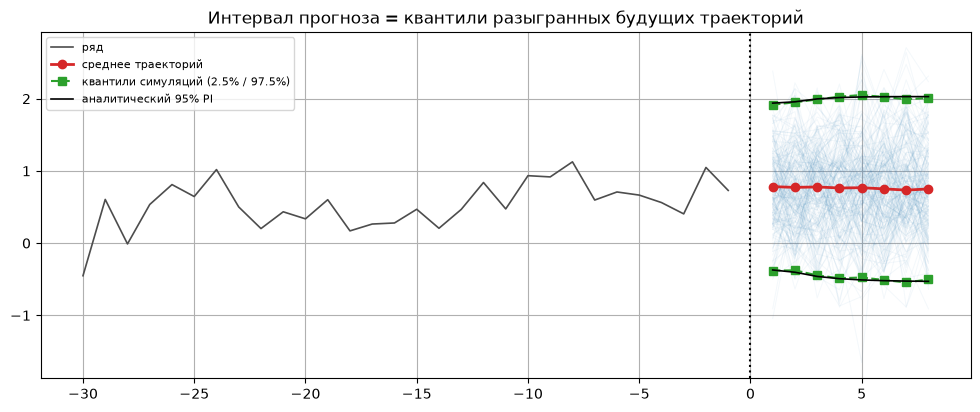

,"квантиль симуляций, низ","аналитически, низ","квантиль симуляций, верх","аналитически, верх"
h,,,,
1,-0.380,-0.372,1.917,1.938
2,-0.377,-0.403,1.950,1.957
3,-0.446,-0.461,1.989,1.997
4,-0.486,-0.493,2.028,2.016
5,-0.476,-0.510,2.051,2.024
6,-0.511,-0.520,2.024,2.028
7,-0.545,-0.526,1.992,2.029
8,-0.504,-0.529,2.009,2.029


In [28]:
res_sim = ARIMA(consumption, order=(1, 0, 2), trend="c").fit()
H = 8
n_paths = 5000

paths = np.asarray(
    res_sim.simulate(H, anchor="end", repetitions=n_paths,
                     random_state=np.random.default_rng(1))
).reshape(H, n_paths)

lo_sim, hi_sim = np.percentile(paths, [2.5, 97.5], axis=1)
ci_ana = np.asarray(res_sim.get_forecast(H).conf_int())

fig, ax = plt.subplots(figsize=(12, 4.5))
hist = consumption.to_numpy()[-30:]
ax.plot(np.arange(-30, 0), hist, color="0.3", lw=1.2, label="ряд")
xs = np.arange(1, H + 1)
for k in range(200):
    ax.plot(xs, paths[:, k], color="tab:blue", alpha=0.05, lw=0.7)
ax.plot(xs, paths.mean(axis=1), "o-", color="tab:red", lw=2, label="среднее траекторий")
ax.plot(xs, lo_sim, "s--", color="tab:green", label="квантили симуляций (2.5% / 97.5%)")
ax.plot(xs, hi_sim, "s--", color="tab:green")
ax.plot(xs, ci_ana[:, 0], "-", color="k", lw=1.2, label="аналитический 95% PI")
ax.plot(xs, ci_ana[:, 1], "-", color="k", lw=1.2)
ax.axvline(0, color="k", ls=":")
ax.set_title("Интервал прогноза = квантили разыгранных будущих траекторий")
ax.legend(fontsize=8)
plt.show()

pd.DataFrame({
    "квантиль симуляций, низ": lo_sim,
    "аналитически, низ": ci_ana[:, 0],
    "квантиль симуляций, верх": hi_sim,
    "аналитически, верх": ci_ana[:, 1],
}, index=pd.Index(xs, name="h")).round(3)

Совпадение с точностью до случайного шума симуляции (третий знак при 5000
траекториях). Увеличьте `n_paths` — разница уменьшится как
$1/\sqrt{n_{\text{paths}}}$.

---
# 6. Роль $c$ и $d$: шесть форм долгосрочного прогноза

В ноутбуке `01` мы посмотрели на формы долгосрочного прогноза качественно.
Теперь у нас есть формулы, и можно сказать точно: **форма долгосрочного
прогноза полностью определяется парой ($d$, наличие константы)** и не
зависит от $p$ и $q$. Значения $p$ и $q$ влияют только на первые несколько
шагов — потом «включается» асимптотика.

| | $c = 0$ | $c \ne 0$ |
|---|---|---|
| $d = 0$ | горизонталь на нуле | горизонталь на уровне $\mu$ |
| $d = 1$ | горизонталь на уровне последнего наблюдения | прямая с наклоном |
| $d = 2$ | прямая с наклоном | парабола |

## 6.1. Как это задаётся в `statsmodels`

Здесь есть неочевидность, из-за которой ломается много кода. Параметр
`trend` в `statsmodels` описывает многочлен от $t$, добавляемый к
**исходному** (непродифференцированному) ряду:

* `trend="n"` — ничего;
* `trend="c"` — константа;
* `trend="t"` — линейный член $\beta t$;
* `trend=[0, 0, 1]` — квадратичный член $\beta t^2$ (список задаёт, какие
  степени $t^0, t^1, t^2$ включены).

После взятия $d$ разностей многочлен степени $k$ превращается в многочлен
степени $k - d$. Поэтому:

* при $d = 1$ «константа в модели для разностей» — это `trend="t"`;
* при $d = 2$ — это `trend=[0, 0, 1]`.

А `trend="c"` при $d \ge 1$ библиотека просто запретит: такой член
уничтожается дифференцированием.

In [29]:
try:
    ARIMA(y_googl, order=(1, 1, 0), trend="c").fit()
except ValueError as err:
    print("ValueError:", str(err)[:220], "...")

ValueError: In models with integration (`d > 0`) or seasonal integration (`D > 0`), trend terms of lower order than `d + D` cannot be (as they would be eliminated due to the differencing operation). For example, a constant cannot be ...


## 6.2. Сетка 2×3

Возьмём один и тот же ряд (случайное блуждание со сносом) и подгоним шесть
моделей.

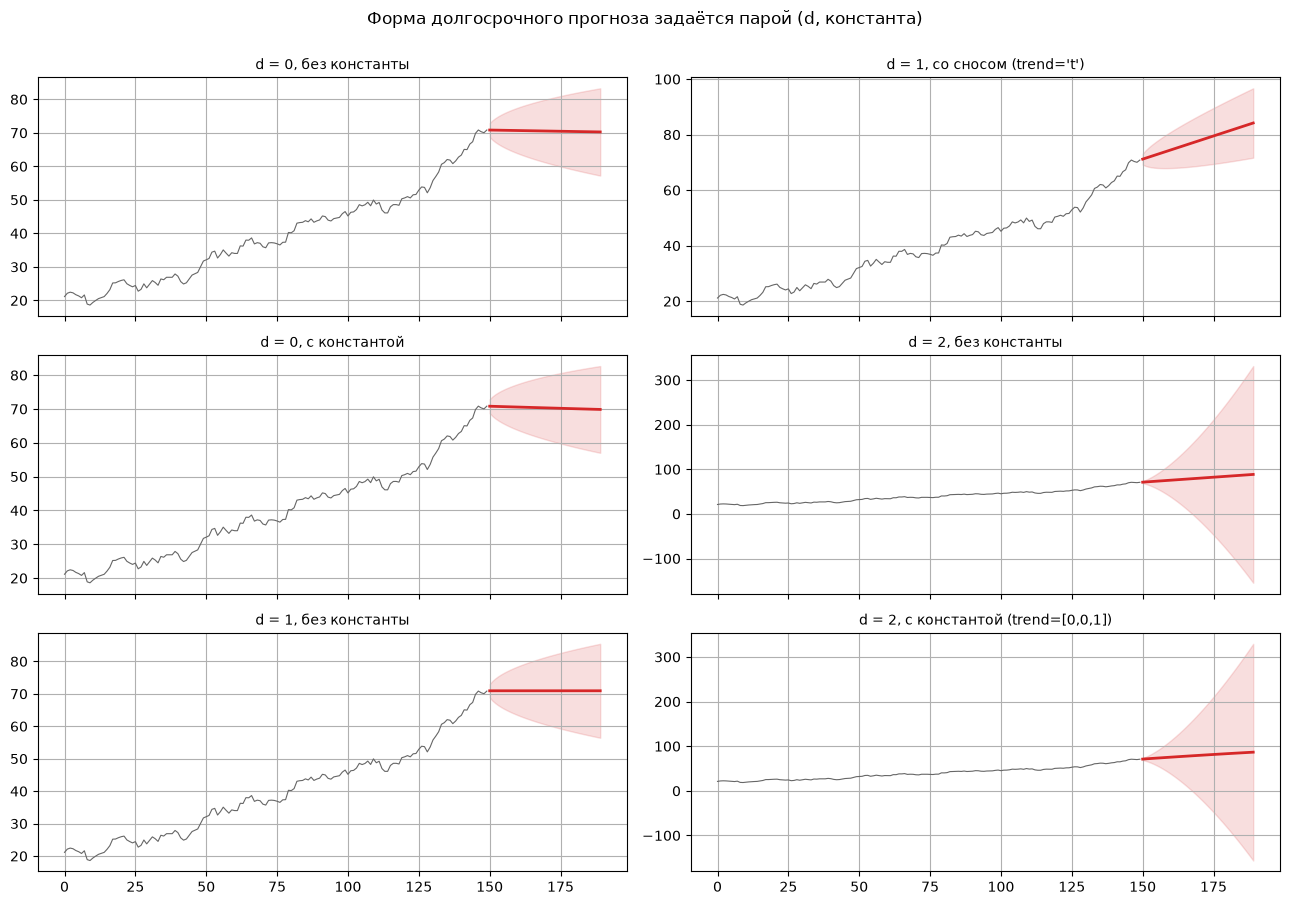

In [30]:
y_walk = np.cumsum(0.3 + rng().standard_normal(150)) + 20

grid = [
    ((1, 0, 0), "n", "d = 0, без константы"),
    ((1, 0, 0), "c", "d = 0, с константой"),
    ((1, 1, 0), "n", "d = 1, без константы"),
    ((1, 1, 0), "t", "d = 1, со сносом (trend='t')"),
    ((1, 2, 0), "n", "d = 2, без константы"),
    ((1, 2, 0), [0, 0, 1], "d = 2, с константой (trend=[0,0,1])"),
]

H = 40
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
for ax, (order, trend, title) in zip(axes.T.ravel(), grid):
    r = ARIMA(y_walk, order=order, trend=trend).fit()
    fc = r.get_forecast(H)
    idx = np.arange(len(y_walk), len(y_walk) + H)
    ci = np.asarray(fc.conf_int())
    ax.plot(np.arange(len(y_walk)), y_walk, lw=0.8, color="0.4")
    ax.plot(idx, fc.predicted_mean, color="tab:red", lw=2)
    ax.fill_between(idx, ci[:, 0], ci[:, 1], color="tab:red", alpha=0.15)
    ax.set_title(title, fontsize=10)
fig.suptitle("Форма долгосрочного прогноза задаётся парой (d, константа)", y=1.0)
fig.tight_layout()
plt.show()

Проверим формы численно: посмотрим на первую и вторую разности прогноза на
далёком горизонте. У горизонтали первая разность равна нулю, у прямой —
постоянна, у параболы постоянна вторая разность.

In [31]:
rows = []
for order, trend, title in grid:
    r = ARIMA(y_walk, order=order, trend=trend).fit()
    f = np.asarray(r.get_forecast(60).predicted_mean)
    rows.append({
        "модель": title,
        "Δ прогноза (h≈60)": np.diff(f)[-1],
        "Δ² прогноза (h≈60)": np.diff(f, 2)[-1],
    })

pd.DataFrame(rows).round(5)

,модель,Δ прогноза (h≈60),Δ² прогноза (h≈60)
0,"d = 0, без константы",-0.01440,0.00000
1,"d = 0, с константой",-0.02338,0.00002
2,"d = 1, без константы",0.00000,0.00000
3,"d = 1, со сносом (trend='t')",0.33370,0.00000
4,"d = 2, без константы",0.44448,0.00000
5,"d = 2, с константой (trend=[0,0,1])",0.30835,-0.00226


🔍 **Практическое предупреждение.** Последняя строка — парабола: прогноз
ускоряется, и на горизонте в сотню шагов улетит куда угодно. Именно поэтому
библиотеки по умолчанию не включают константу при $d \ge 2$, а Хайндман
советует не использовать $d = 2$ с константой вовсе. Если ваш долгосрочный
прогноз «взорвался» — первым делом смотрите на эту пару.

---
# 7. Как $d$ влияет на скорость расширения интервалов

Из формулы $v_{T+h} = \sigma^2 \sum_{j<h}\psi_j^2$ сразу следует поведение
ширины интервала:

| $d$ | веса $\psi_j$ | $v_{T+h}$ | ширина PI |
|---|---|---|---|
| 0 | затухают геометрически | сходится к $\mathrm{Var}(y)$ | выходит на константу |
| 1 | стремятся к константе | растёт как $h$ | растёт как $\sqrt{h}$ |
| 2 | растут линейно | растёт как $h^3$ | растёт как $h^{1.5}$ |

Проверим это на одном ряду и на одной картинке.

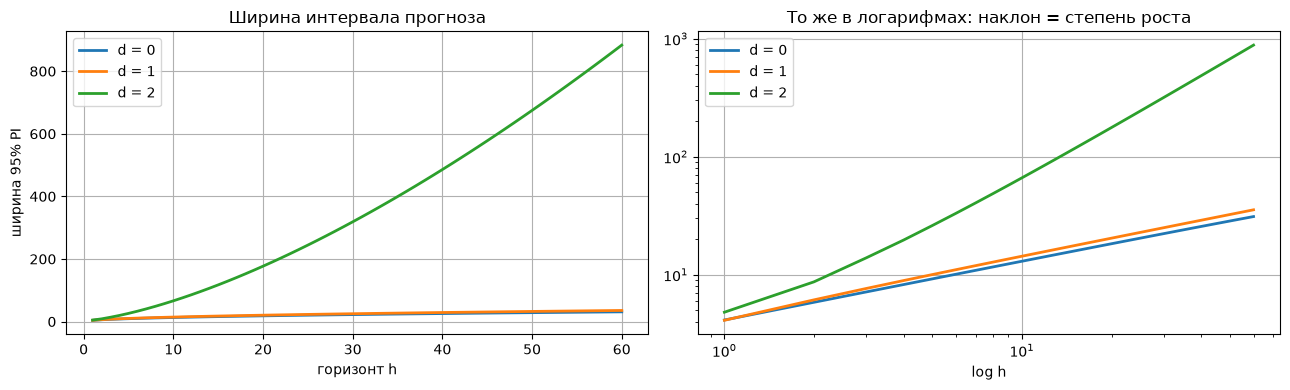

In [32]:
H = 60
hh = np.arange(1, H + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
widths = {}
for d_, order, trend in [(0, (1, 0, 0), "c"), (1, (1, 1, 0), "n"), (2, (1, 2, 0), "n")]:
    r = ARIMA(y_walk, order=order, trend=trend).fit()
    ci = np.asarray(r.get_forecast(H).conf_int())
    wdt = ci[:, 1] - ci[:, 0]
    widths[f"d = {d_}"] = wdt
    axes[0].plot(hh, wdt, lw=2, label=f"d = {d_}")
    axes[1].loglog(hh, wdt, lw=2, label=f"d = {d_}")

axes[0].set_xlabel("горизонт h"); axes[0].set_ylabel("ширина 95% PI")
axes[0].set_title("Ширина интервала прогноза"); axes[0].legend()
axes[1].set_xlabel("log h"); axes[1].set_title("То же в логарифмах: наклон = степень роста")
axes[1].legend()
fig.tight_layout()
plt.show()

In [33]:
# наклон в логарифмических координатах на «хвосте» — это и есть показатель степени
slopes = {
    k: np.polyfit(np.log(hh[20:]), np.log(v[20:]), 1)[0] for k, v in widths.items()
}
pd.DataFrame({"эмпирический наклон log-log": slopes,
              "теория": {"d = 0": 0.0, "d = 1": 0.5, "d = 2": 1.5}}).round(3)

,эмпирический наклон log-log,теория
d = 0,0.482,0.0
d = 1,0.503,0.5
d = 2,1.466,1.5


Эмпирические наклоны ложатся на теоретические $0$, $0.5$, $1.5$.

🔑 Практический вывод: **выбор $d$ — это не только выбор формы прогноза, но и
выбор того, как быстро вы признаёте своё незнание будущего.** Лишняя разность
делает интервалы неоправданно широкими, недостающая — неоправданно узкими,
причём ошибка накапливается с горизонтом.

---
# 8. Почему интервалы ARIMA систематически слишком узкие

Мы аккуратно вывели интервал и сверили его с библиотекой. Значит ли это, что
в 95% случаев будущее окажется внутри 95%-го интервала? **Нет.** И это не
мелкая поправка, а систематическое смещение.

Посмотрим на список допущений, которые мы сделали по дороге:

1. **Параметры считаются известными точно.** Мы подставили $\hat\varphi$,
   $\hat\theta$, $\hat\sigma^2$ в формулы так, как будто это истинные
   значения. На деле они оценены по конечной выборке и сами случайны — эта
   неопределённость в интервал **не заложена**.
2. **Модель считается правильной и неизменной.** Предполагается, что
   порядок $(p, d, q)$ угадан верно и что механизм, породивший данные, не
   изменится на горизонте прогноза.
3. **Ошибки считаются нормальными, независимыми и одинаково
   распределёнными.** У реальных рядов (особенно финансовых) хвосты тяжелее
   нормальных, а дисперсия непостоянна — волатильность кластеризуется.

Каждое допущение работает в одну и ту же сторону — **сужает** интервал.
Проверим это двумя экспериментами.

## 8.1. Монте-Карло: цена оценённых параметров

Чтобы изолировать причину №1, возьмём **правильную** модель: сгенерируем
AR(1) и будем подгонять AR(1). Допущения 2 и 3 выполнены по построению —
остаётся только неопределённость оценок. Если она ни на что не влияет,
покрытие должно быть 95%.

In [34]:
def coverage_experiment(n, n_rep=300, H=4, phi_true=0.7, seed=7):
    """Доля попаданий будущего в 95% PI: модель верна, параметры оценены."""
    gen = np.random.default_rng(seed)
    proc = ArmaProcess.from_coeffs([phi_true], [])
    hits, cnt = np.zeros(H), 0
    for _ in range(n_rep):
        y = proc.generate_sample(n + H, distrvs=gen.standard_normal)
        r = ARIMA(y[:n], order=(1, 0, 0), trend="c").fit()
        ci = np.asarray(r.get_forecast(H).conf_int())
        hits += (y[n:] >= ci[:, 0]) & (y[n:] <= ci[:, 1])
        cnt += 1
    return hits / cnt


cov = pd.DataFrame(
    {f"n = {n}": coverage_experiment(n) for n in (50, 200)},
    index=pd.Index(range(1, 5), name="горизонт h"),
)
cov["номинальный уровень"] = 0.95
cov.round(3)

,n = 50,n = 200,номинальный уровень
горизонт h,,,
1,0.900,0.950,0.95
2,0.870,0.937,0.95
3,0.887,0.950,0.95
4,0.857,0.937,0.95


На короткой выборке ($n = 50$) реальное покрытие — около 86–90% вместо
заявленных 95%. То есть «95%-й интервал» на самом деле примерно 88%-й.
На длинной выборке ($n = 200$) расхождение почти исчезает: оценки точнее,
и допущение «параметры известны» становится безобидным.

🔑 **Чем короче ряд и чем больше параметров в модели, тем сильнее интервалы
ARIMA врут в сторону оптимизма.**

## 8.2. Реальные данные: кросс-валидация по скользящему началу

Теперь снимем и остальные допущения — возьмём реальный ряд, где модель
заведомо не идеальна. Процедура (rolling origin):

* берём первые $t$ наблюдений, подгоняем модель, строим PI на $h = 1..4$;
* смотрим, попали ли реальные значения внутрь;
* сдвигаем $t$ на шаг и повторяем.

In [35]:
def rolling_coverage(y, order, trend, start, H=4, step=1):
    """Доля попаданий фактических значений в 95% PI при скользящем начале."""
    y = np.asarray(y, dtype=float)
    hits, tot = np.zeros(H), 0
    for t in range(start, len(y) - H, step):
        try:
            r = ARIMA(y[:t], order=order, trend=trend).fit()
        except Exception:
            continue
        ci = np.asarray(r.get_forecast(H).conf_int())
        act = y[t:t + H]
        hits += (act >= ci[:, 0]) & (act <= ci[:, 1])
        tot += 1
    return hits / tot, tot


sunspots = pd.read_csv("../data/monthly-sunspots.csv").iloc[:, 1].astype(float)

experiments = {}
for name, y_, order, trend, start, step in [
    ("log GOOGL, ARIMA(0,1,0)", y_googl, (0, 1, 0), "n", 100, 1),
    ("log GOOGL, ARIMA(1,1,1)", y_googl, (1, 1, 1), "n", 100, 1),
    ("Sunspots, ARIMA(2,0,1)", sunspots.iloc[:600], (2, 0, 1), "c", 200, 3),
    ("US consumption, ARIMA(1,0,3)", y_cons, (1, 0, 3), "c", 80, 1),
]:
    cov_, tot = rolling_coverage(y_, order, trend, start, step=step)
    experiments[name] = np.r_[cov_, tot]

pd.DataFrame(
    experiments, index=pd.Index([f"h = {i}" for i in range(1, 5)] + ["число origin'ов"])
).round(3)

,"log GOOGL, ARIMA(0,1,0)","log GOOGL, ARIMA(1,1,1)","Sunspots, ARIMA(2,0,1)","US consumption, ARIMA(1,0,3)"
h = 1,0.946,0.946,0.947,0.981
h = 2,0.934,0.928,0.917,0.981
h = 3,0.916,0.916,0.902,0.971
h = 4,0.922,0.928,0.909,0.971
число origin'ов,166.000,166.000,132.000,103.000


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood opti

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood opti

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"log GOOGL, ARIMA(0,1,0)","log GOOGL, ARIMA(1,1,1)","Sunspots, ARIMA(2,0,1)","US consumption, ARIMA(1,0,3)"
h = 1,0.946,0.946,0.947,0.981
h = 2,0.934,0.928,0.917,0.981
h = 3,0.916,0.916,0.902,0.971
h = 4,0.922,0.928,0.909,0.971
число origin'ов,166.000,166.000,132.000,103.000


Читаем таблицу честно, строка за строкой:

* **log GOOGL** — покрытие 92–95% на $h=1$ и падает до ~92% на $h=4$.
  Недобор небольшой, но систематический и растущий с горизонтом. Причина
  номер 3: у дневных лог-доходностей тяжёлые хвосты и кластеризация
  волатильности, а модель считает дисперсию постоянной.
* **Sunspots** с несезонной AR(2,0,1) — покрытие ~91%. Здесь работает
  причина номер 2: модель заведомо неверна, у ряда есть цикл длиной ~11 лет,
  который ARMA такого порядка не описывает.
* **US consumption** — покрытие **выше** 95%. Так тоже бывает: ряд короткий,
  спокойный, модель для него достаточно богата. Интервалы получаются
  консервативными.

🔍 Вывод не «интервалы ARIMA всегда узкие», а более аккуратный: **их
фактическое покрытие неизвестно и его надо измерять**. Формула из раздела 5
даёт интервал, верный *внутри модели*, а не *в реальности*.

## 8.3. Что с этим делают

Отсюда растут две большие темы курса:

* **Бутстреп для временных рядов** — вместо нормальности разыгрываем
  будущие шоки из эмпирического распределения остатков (или блоками, чтобы
  сохранить зависимость). Учитывает тяжёлые хвосты и асимметрию — то есть
  лечит причину номер 3. Симуляционную машинку для этого мы уже собрали в
  разделе 5.6, надо лишь поменять источник шоков.
* **Конформное прогнозирование (conformal prediction)** — интервал строится
  не из модели, а из **фактических ошибок на отложенной выборке**. Он даёт
  гарантию покрытия при минимальных предположениях и вообще не зависит от
  того, правильно ли выбран $(p,d,q)$ — то есть лечит сразу все три причины.

Для иллюстрации сделаем один шаг в сторону бутстрепа: сравним нормальный
интервал с интервалом по квантилям остатков.

нормальное приближение, h=1: [-0.0353, +0.0353]
квантили остатков,      h=1: [-0.0281, +0.0302]
эксцесс остатков: 16.83 (у нормального 0)


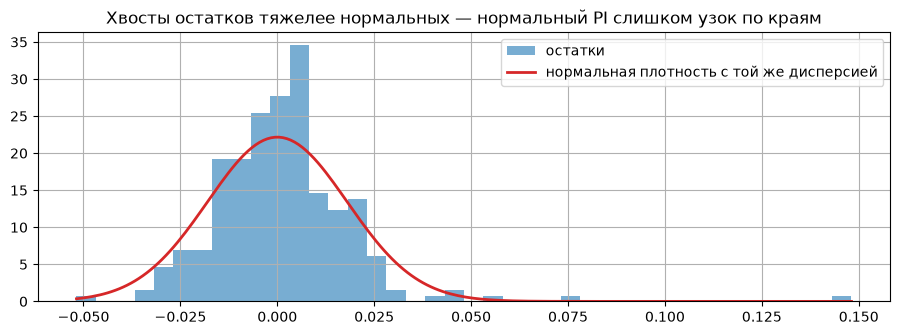

In [36]:
res_boot = ARIMA(y_googl, order=(1, 1, 1), trend="n").fit()
resid = np.asarray(res_boot.resid)[10:]     # выбрасываем «разогрев»

norm_lo, norm_hi = -z * resid.std(), z * resid.std()
emp_lo, emp_hi = np.percentile(resid, [2.5, 97.5])

print(f"нормальное приближение, h=1: [{norm_lo:+.4f}, {norm_hi:+.4f}]")
print(f"квантили остатков,      h=1: [{emp_lo:+.4f}, {emp_hi:+.4f}]")
print(f"эксцесс остатков: {stats.kurtosis(resid):.2f} (у нормального 0)")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.hist(resid, bins=40, density=True, alpha=0.6, label="остатки")
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, 0, resid.std()), lw=2, color="tab:red",
        label="нормальная плотность с той же дисперсией")
ax.set_title("Хвосты остатков тяжелее нормальных — нормальный PI слишком узок по краям")
ax.legend()
plt.show()

Положительный эксцесс означает: экстремальные значения случаются чаще, чем
предсказывает нормальное распределение. Именно они и «протыкают» интервал.

---
# Итоги

* **Прогноз ARIMA — это рецепт из трёх шагов:** развернуть уравнение,
  заменить $t \to T+h$, подставить прогнозы вместо будущих $y$, нули вместо
  будущих $\varepsilon$ и остатки вместо прошлых (раздел 1).
* **MA($q$): прогноз выходит на $\mu$ ровно за $q$ шагов**, AR($p$):
  затухает к $\mu$ геометрически и никогда не достигает точно
  (разделы 2–3).
* **При $d \ge 1$ прогнозируем разность, потом интегрируем обратно.**
  Раскрытие скобок $(1-\varphi(L))(1-L)^d$ даёт $p + d$ лагов $y$
  (раздел 4).
* **Всё это воспроизводится вручную с точностью $10^{-11}$.** Если
  расхождение вдруг оказалось на уровне $10^{-5}$ — почти наверняка
  MA-корень близок к единичной окружности, то есть ряд передифференцирован
  (раздел 4.4).
* **Ключевая формула интервалов:** $v_{T+h\mid T} = \sigma^2 \sum_{j<h}\psi_j^2$,
  где $\psi_j$ — веса представления MA($\infty$). Из неё следует всё
  остальное (раздел 5).
* **$v_{T+1\mid T} = \hat\sigma^2$ для любой ARIMA** — одношаговый интервал
  всегда равен $\hat y_{T+1} \pm 1.96\,\hat\sigma$ (раздел 5.2).
* **Интервал = квантили разыгранных траекторий**; аналитическая формула —
  лишь быстрый способ получить те же числа (раздел 5.6).
* **Пара ($d$, константа) определяет форму долгосрочного прогноза**
  (горизонталь / прямая / парабола) и скорость роста интервала
  (константа / $\sqrt{h}$ / $h^{1.5}$) — независимо от $p$ и $q$
  (разделы 6–7).
* **Фактическое покрытие интервалов ARIMA не равно номинальному.** Три
  причины: неучтённая неопределённость оценок, возможная неверность модели,
  предположение о нормальности. Все три сужают интервал (раздел 8).
